In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [25]:
df = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB3/tvmarketing.csv")

In [26]:
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [27]:
df.dtypes

TV       float64
Sales    float64
dtype: object

In [28]:
df.shape

(200, 2)

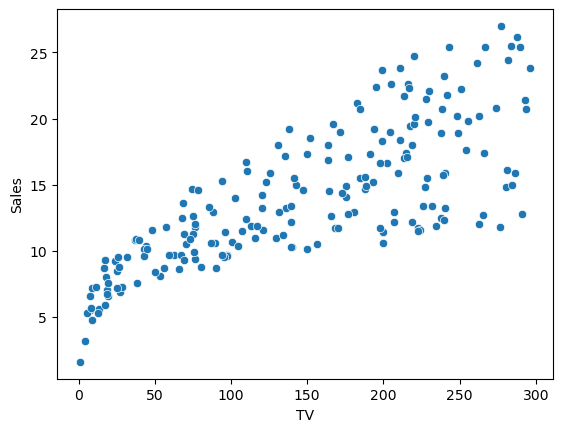

In [29]:
sns.scatterplot(x="TV", y="Sales", data=df)
plt.show()

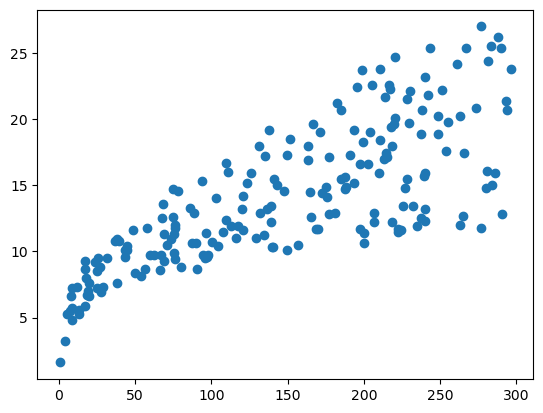

In [30]:
plt.scatter(df["TV"],df["Sales"])
plt.show()

In [60]:
train_size = int(0.7 * len(df))
X = df["TV"].values.flatten()
y = df["Sales"].values

In [61]:
X_train =X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

In [62]:
print("Train Shape: ", X_train.shape)
print("Test Shape: ", X_test.shape)

Train Shape:  (140,)
Test Shape:  (60,)


In [63]:
# y = m * x + b
# m = (y-yb) * (x-xb) / (x-xb)**2
x_mean = np.mean(X_train)
y_mean = np.mean(y_train)
num = np.sum((y_train-y_mean)*(X_train-x_mean))
den = np.sum((X_train-x_mean)**2)
m = num/den
b = y_mean - m * x_mean

In [64]:
print("coeff: ",m)
print("Intercept: ",b)

coeff:  0.04888180899352706
Intercept:  7.11987505481279


In [65]:
y_pred = m * X_test + b

In [66]:
print("mse: ", mean_squared_error(y_test, y_pred))

mse:  12.696573082394831


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train = X_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)

In [72]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [73]:
y_pred = model.predict(X_test)

In [74]:
print("mse: ", mean_squared_error(y_test, y_pred))
print("r2_score: ", r2_score(y_test, y_pred))

mse:  8.970991242413614
r2_score:  0.6714477229302764


In [75]:
print("coeff: ",model.coef_)
print("Intercept: ",model.intercept_)

coeff:  [0.0464078]
Intercept:  7.239459830751138


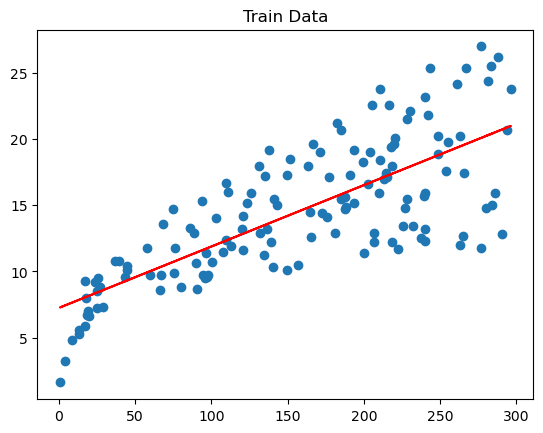

In [76]:
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train), color="r")
plt.title("Train Data")
plt.show()

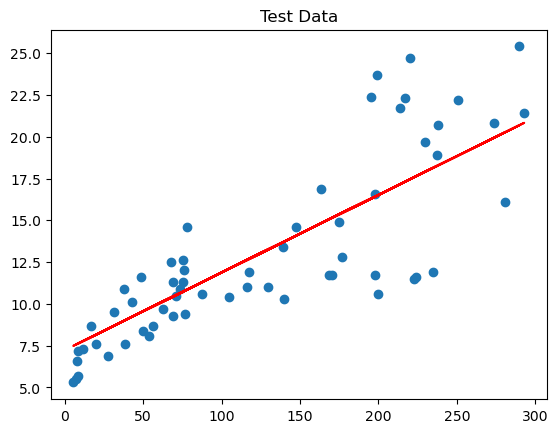

In [77]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred, color="r")
plt.title("Test Data")
plt.show()

In [78]:
# r2 = 1 - (SS_res)/(SS_tot)
r2 = 1 - np.sum((y_test-y_pred)**2)/np.sum((y_test-np.mean(y_test))**2)
print("R2 Score:", r2)

R2 Score: 0.6714477229302764


In [79]:
# adj_r2 = 1 - (n*1)(1-r2)/(n-p-1)
n = len(df)
p = 1
adj_r2 = 1 - (n-1)*(1-r2)/(n-p-1)
print("Adjusted R2:", adj_r2)

Adjusted R2: 0.6697883679955808


## LAB 4

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [82]:
df = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB4/Housing.csv")

In [83]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [84]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [85]:
df.shape

(545, 13)

In [86]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [89]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


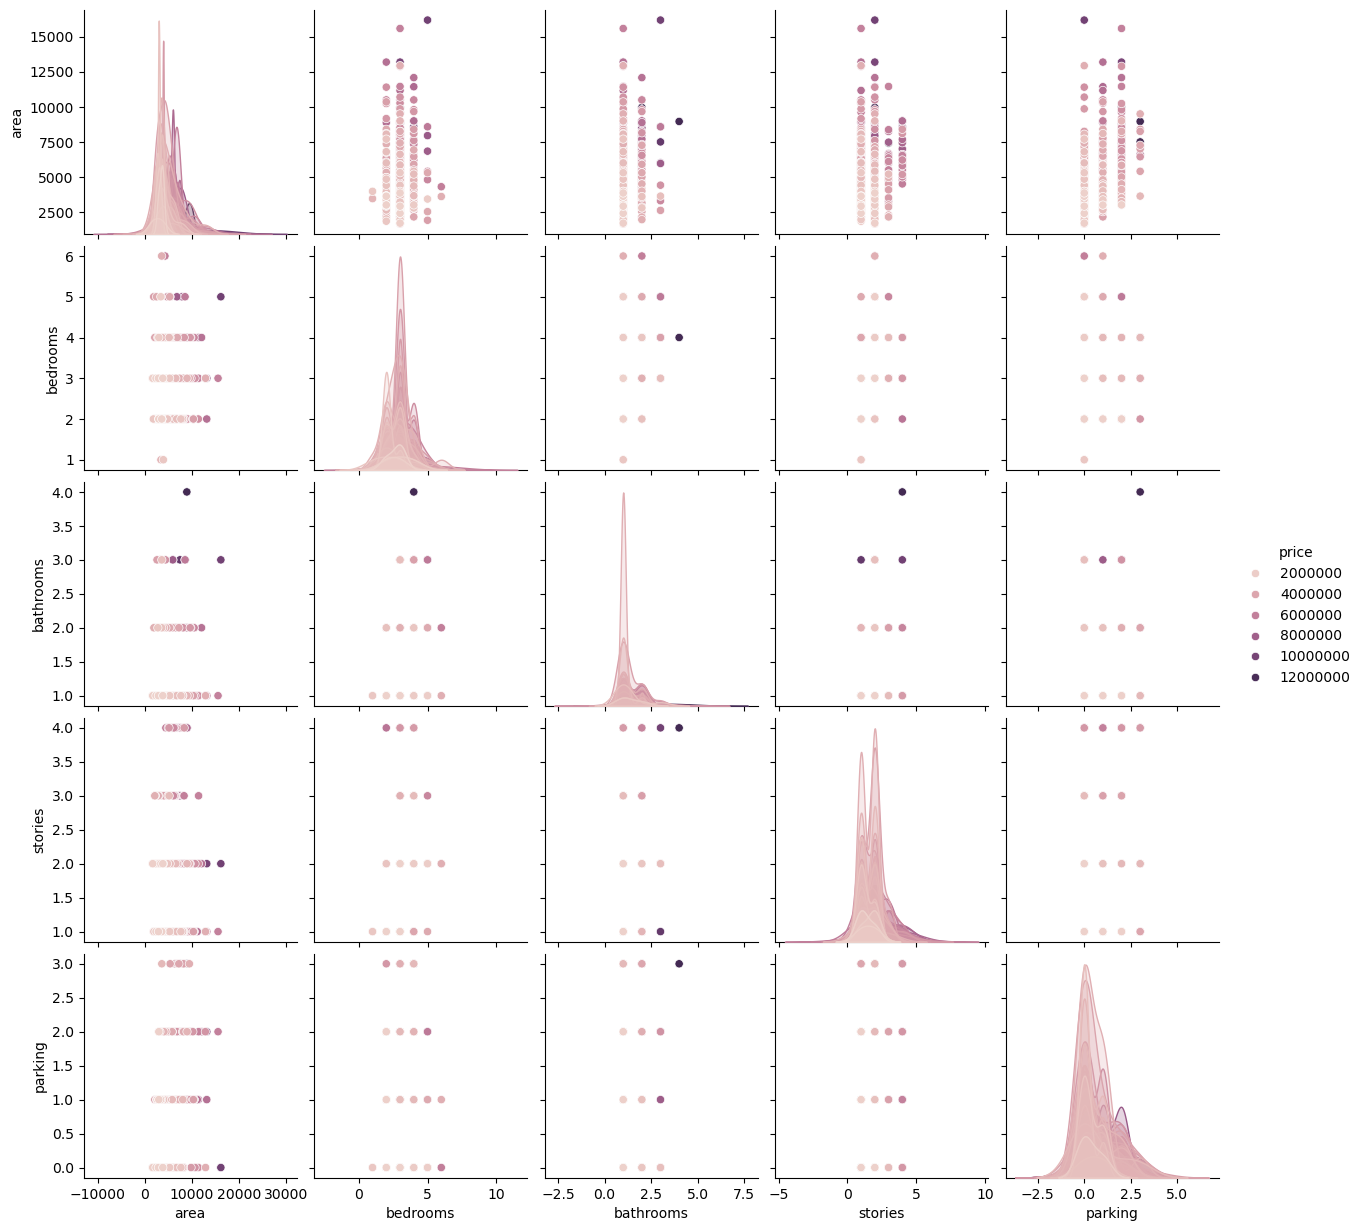

In [90]:
sns.pairplot(data=df,hue="price")
plt.show()

In [91]:
df = pd.get_dummies(df,drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [92]:
X = df.drop("price",axis=1)
y = df["price"]

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [97]:
model = LinearRegression()

In [98]:
model.fit(X_train,y_train)

LinearRegression()

In [99]:
y_pred = model.predict(X_test)

In [100]:
y_train_pred = model.predict(X_train)

In [101]:
error = y_train_pred - y_train

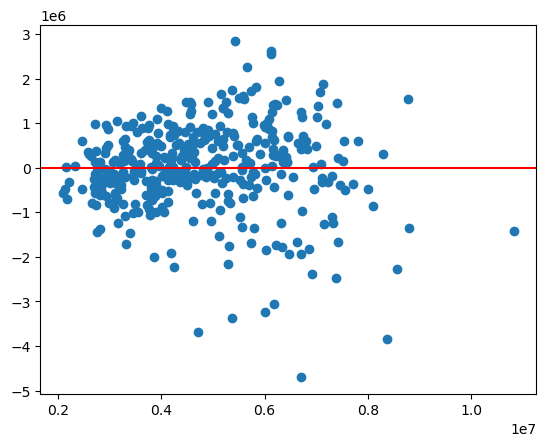

In [104]:
plt.scatter(y_train_pred,error)
plt.axhline(0, color="red")
plt.show()

In [105]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)

Mean Squared Error:  1523019469501.2913
R2 Score:  0.6463350878895877


In [107]:
import statsmodels.api as sm

In [108]:
y_ols = y
X_ols = X
X_ols = sm.add_constant(X_ols)
X_ols = X_ols.astype(float)

In [111]:
SL = 0.05

while True:
    model = sm.OLS(y_ols,X_ols).fit()    
    p_values = model.pvalues

    max_p = p_values.max()
    if max_p > SL:
        feature_to_remove = p_values.idxmax()
        print(f"Removing feature: {feature_to_remove} p-value: {max_p:.4f}")
        X_ols = X_ols.drop(columns=[feature_to_remove],axis=1)
    else:
        break

Removing feature: const p-value: 0.8715
Removing feature: furnishingstatus_semi-furnished p-value: 0.7156
Removing feature: bedrooms p-value: 0.0509


In [113]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):                        0.00
Time:                        11:10:08   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

## LAB 5

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [144]:
df = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB5/train.csv")

In [145]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [146]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [147]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [148]:
df.shape

(891, 12)

In [149]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [150]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

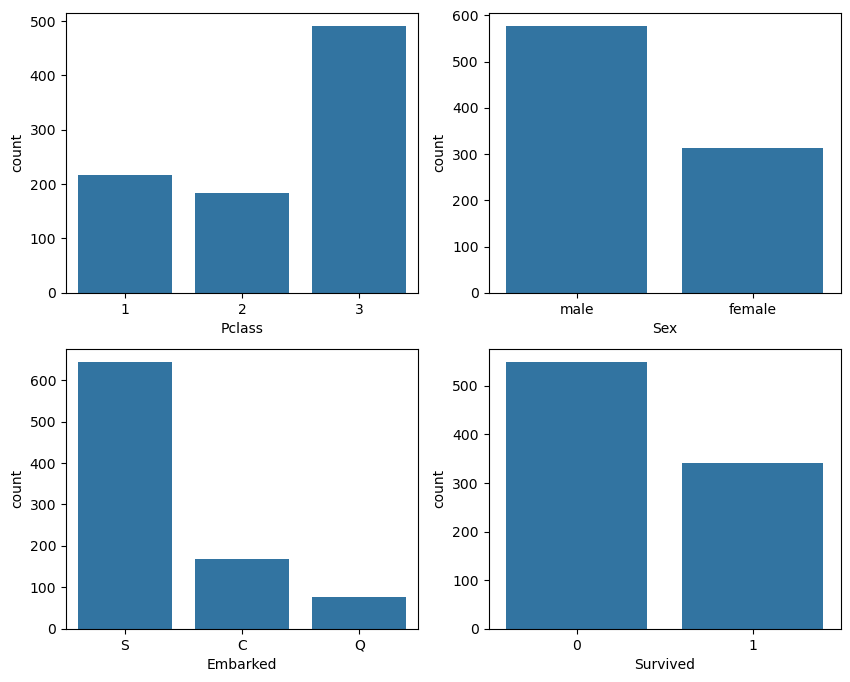

In [151]:
plt.figure(figsize=(10,8))
plt.subplot(221)
sns.countplot(x="Pclass",data=df)
plt.subplot(222)
sns.countplot(x="Sex",data=df)
plt.subplot(223)
sns.countplot(x="Embarked",data=df)
plt.subplot(224)
sns.countplot(x="Survived",data=df)
plt.show()

<Axes: >

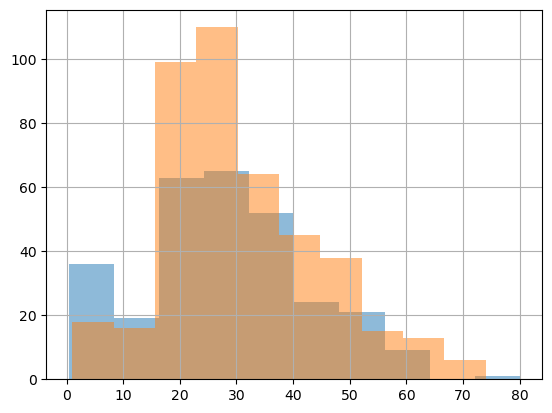

In [152]:
df[df["Survived"]==1]["Age"].hist(alpha=0.5)
df[df["Survived"]==0]["Age"].hist(alpha=0.5)

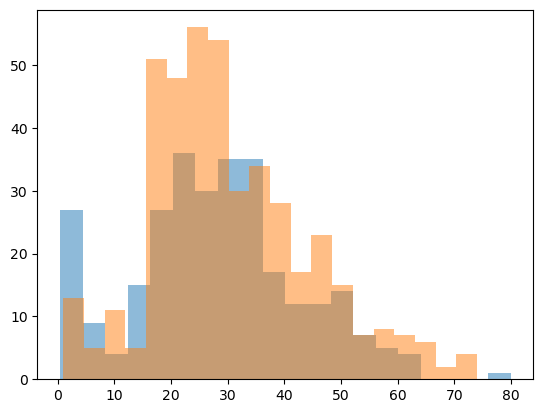

In [153]:
plt.hist(df[df["Survived"]==1]["Age"],bins=20,alpha=0.5)
plt.hist(df[df["Survived"]==0]["Age"],bins=20,alpha=0.5)
plt.show()

In [154]:
df["Embarked"].fillna("S",inplace=True)

/tmp/ipykernel_7116/4172300593.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna("S",inplace=True)


In [155]:
df["Fare"].fillna(df["Fare"].median(),inplace=True)

/tmp/ipykernel_7116/3734075825.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Fare"].fillna(df["Fare"].median(),inplace=True)


In [158]:
mean = df["Age"].mean()
std = df["Age"].std()
missing = df["Age"].isnull().sum()

random_age = np.random.randint(mean-std,mean+std,size=missing)
df.loc[df["Age"].isnull(),"Age"] = random_age

In [160]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [161]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize'],
      dtype='object')

In [162]:
df["IsAlone"]  = False

In [163]:
df.loc[df["FamilySize"]==1,"IsAlone"] = True

In [164]:
df["IsAlone"].value_counts()

IsAlone
True     537
False    354
Name: count, dtype: int64

In [174]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"],inplace=True)

In [175]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,2,False
1,1,1,female,38.0,1,0,71.2833,C,2,False
2,1,3,female,26.0,0,0,7.9250,S,1,True
3,1,1,female,35.0,1,0,53.1000,S,2,False
4,0,3,male,35.0,0,0,8.0500,S,1,True


In [181]:
df = pd.get_dummies(df,drop_first=True)

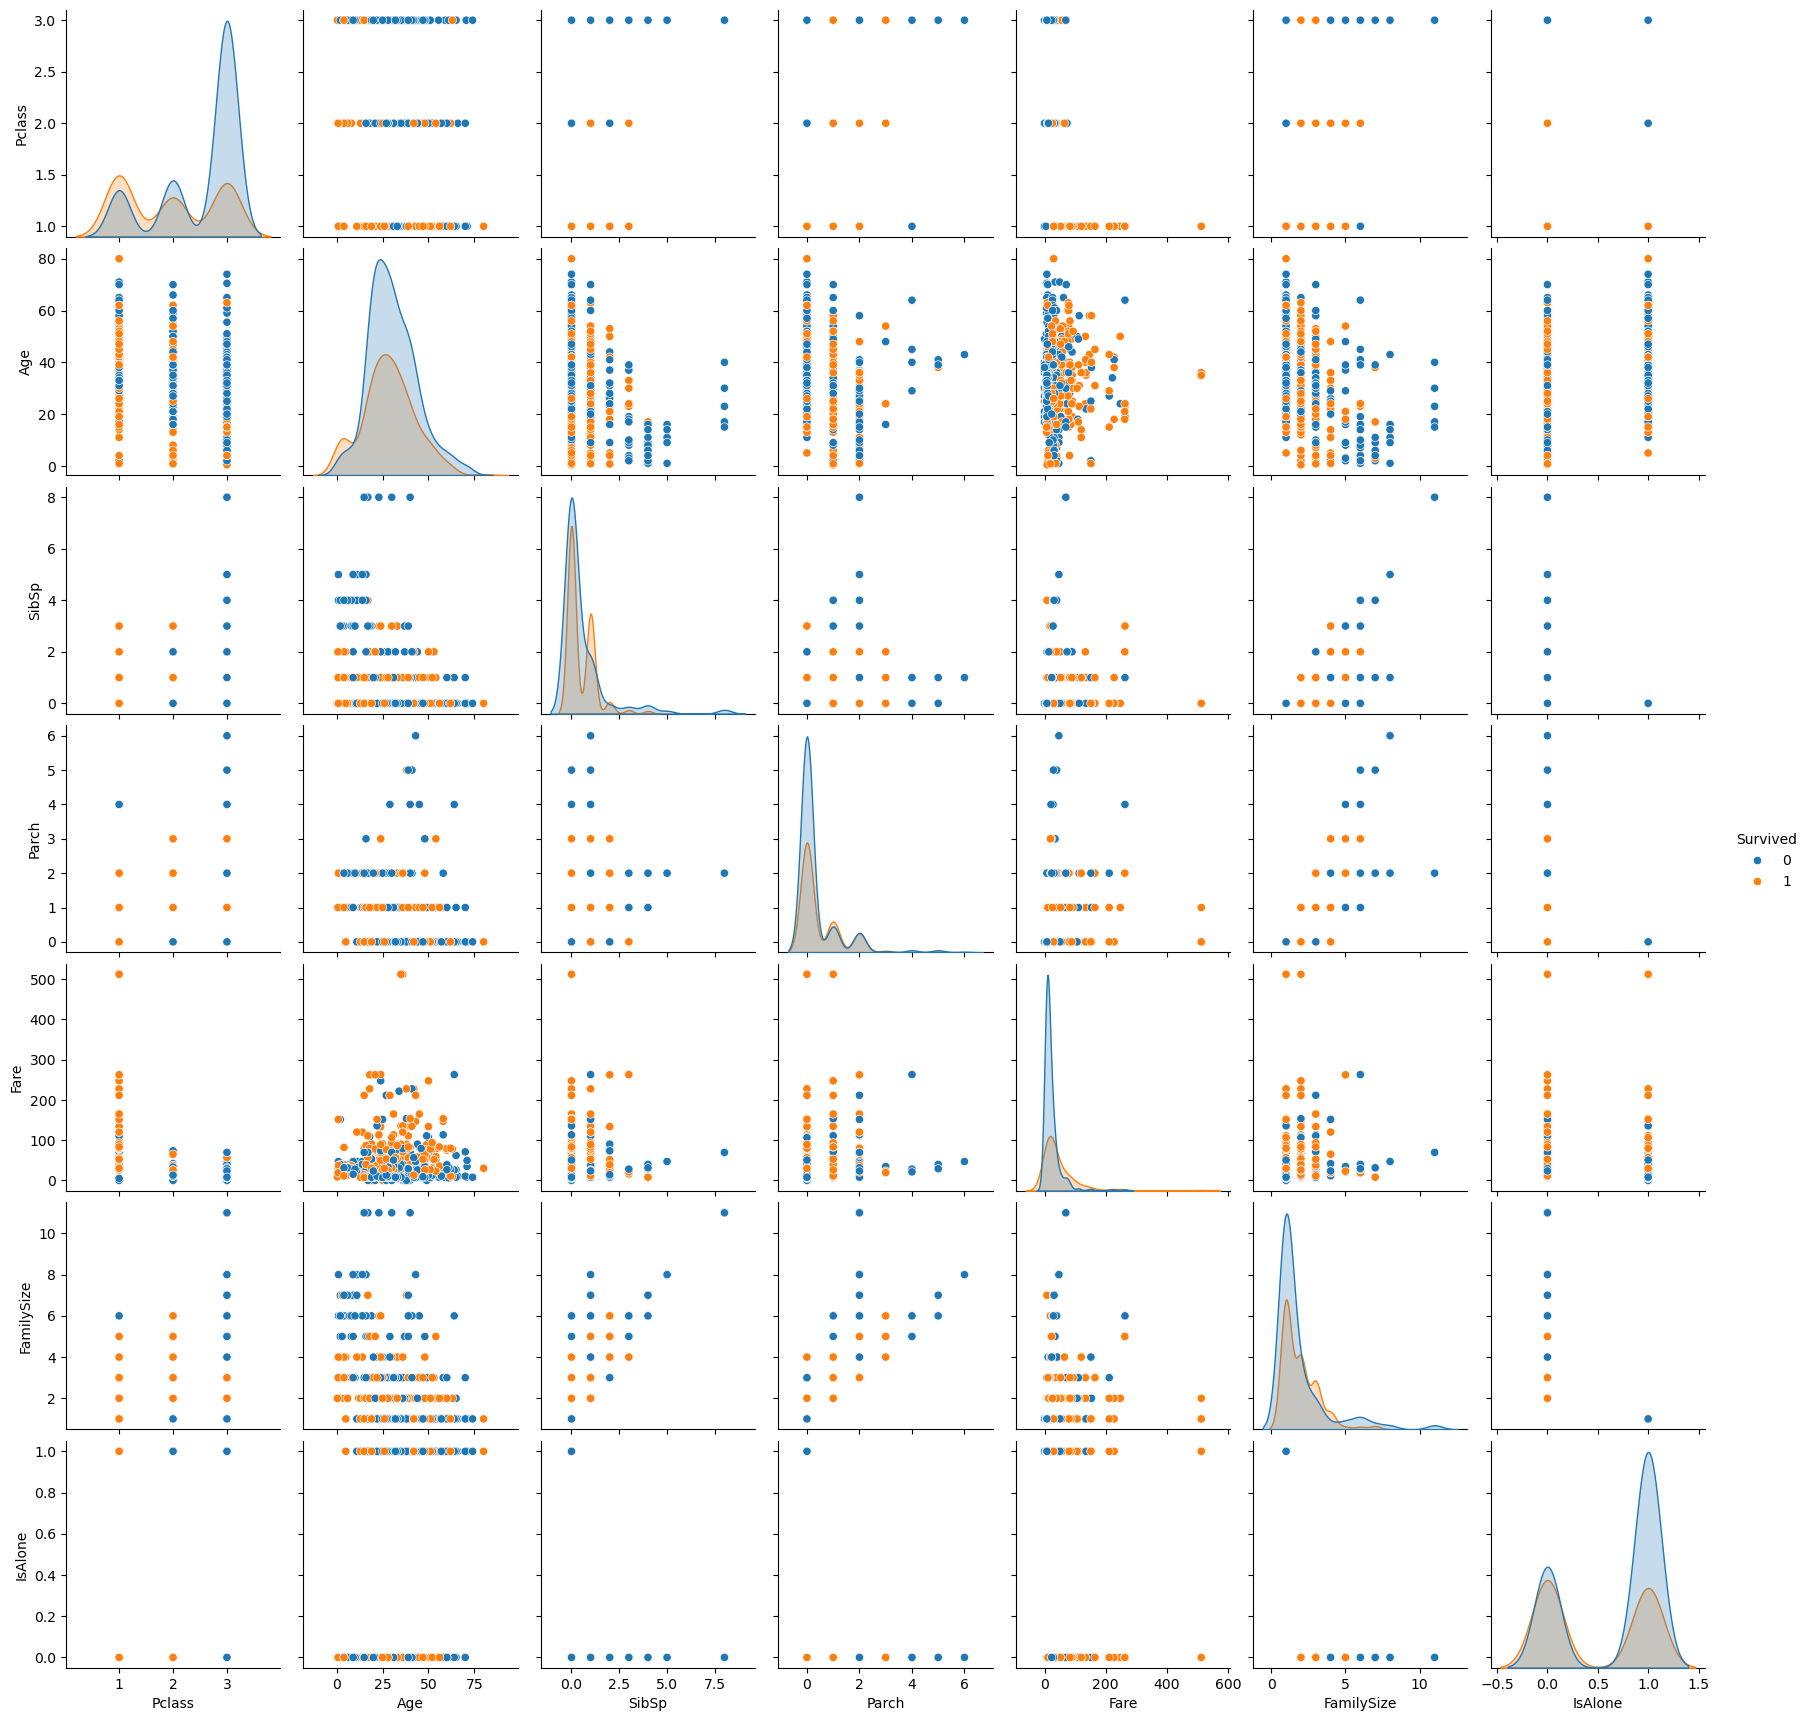

In [176]:
sns.pairplot(data=df,hue="Survived")
plt.show()

In [182]:
X = df.drop("Survived",axis=1)
y = df["Survived"]
X.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,2,False,True,False,True
1,1,38.0,1,0,71.2833,2,False,False,False,False
2,3,26.0,0,0,7.9250,1,True,False,False,True
3,1,35.0,1,0,53.1000,2,False,False,False,True
4,3,35.0,0,0,8.0500,1,True,True,False,True


In [183]:
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=42)

In [184]:
model = DecisionTreeClassifier()

In [185]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

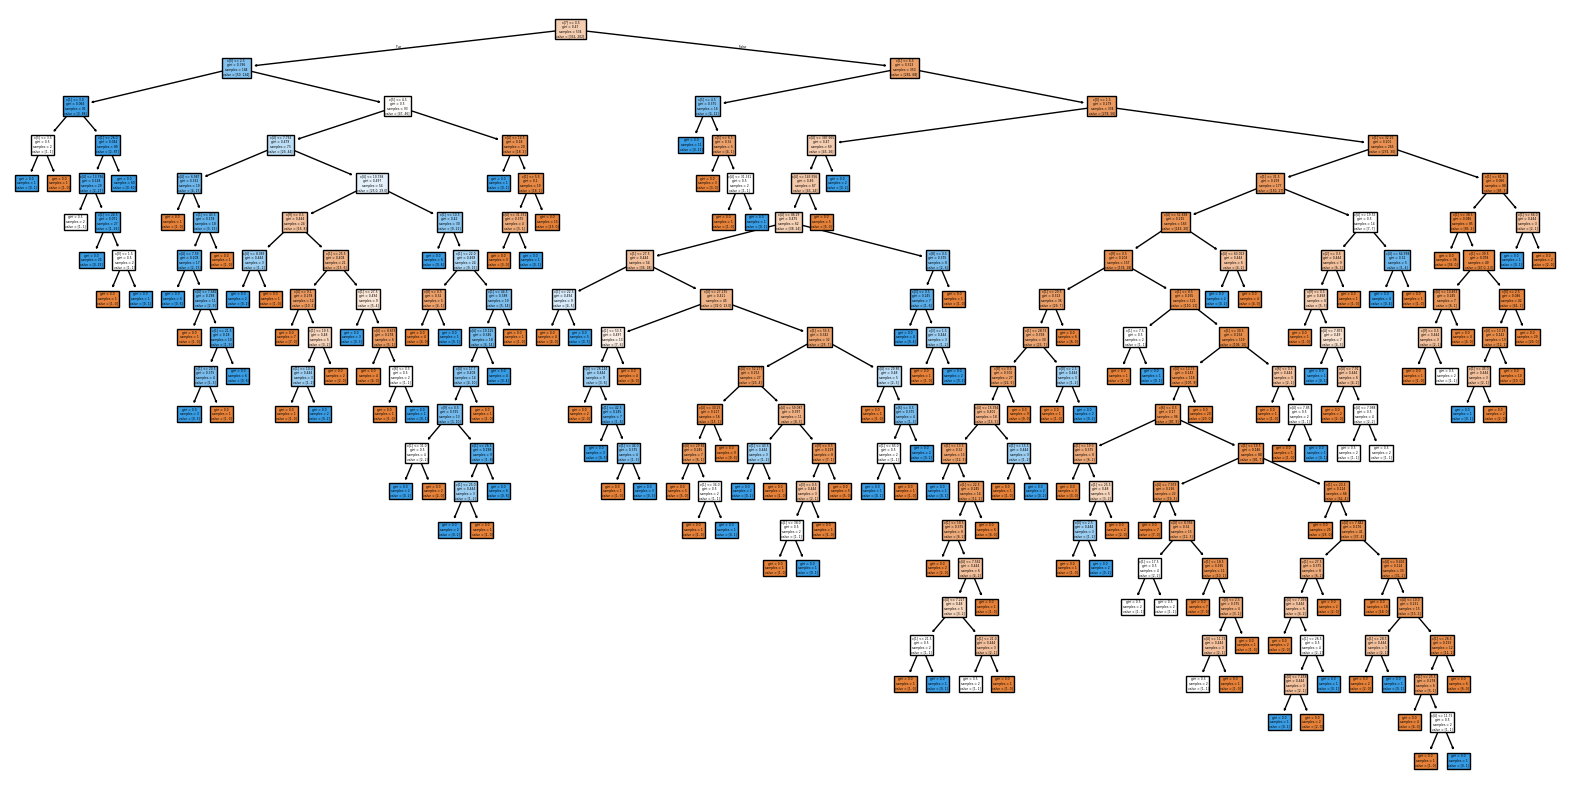

In [188]:
plt.figure(figsize=(20,10))
plot_tree(model,filled=True)
plt.show()

In [189]:
y_pred = model.predict(X_test)

In [190]:
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))
print("Accuracy Score: ",accuracy_score(y_test,y_pred))

Confusion Matrix:  [[84 21]
 [16 58]]
Classification Report:                precision    recall  f1-score   support

           0       0.84      0.80      0.82       105
           1       0.73      0.78      0.76        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179

Accuracy Score:  0.7932960893854749


In [191]:
from sklearn.model_selection import GridSearchCV

In [196]:
param_grid = {
    "max_depth" : range(2,21)
}
grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5
)

In [197]:
grid.fit(X_val,y_val)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': range(2, 21)})

In [198]:
print("best max_depth: ", grid.best_params_)

best max_depth:  {'max_depth': 5}


In [201]:
accuracies = grid.cv_results_["mean_test_score"]

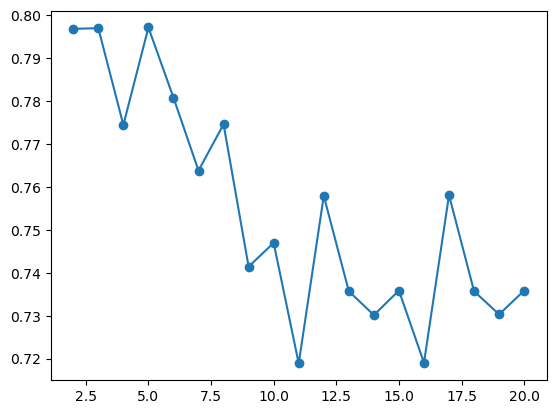

In [204]:
plt.plot(param_grid["max_depth"],accuracies, marker="o")
plt.show()

In [205]:
print("Best Score: ",grid.best_score_)

Best Score:  0.7971428571428572


In [207]:
model = DecisionTreeClassifier(max_depth=grid.best_params_["max_depth"])
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

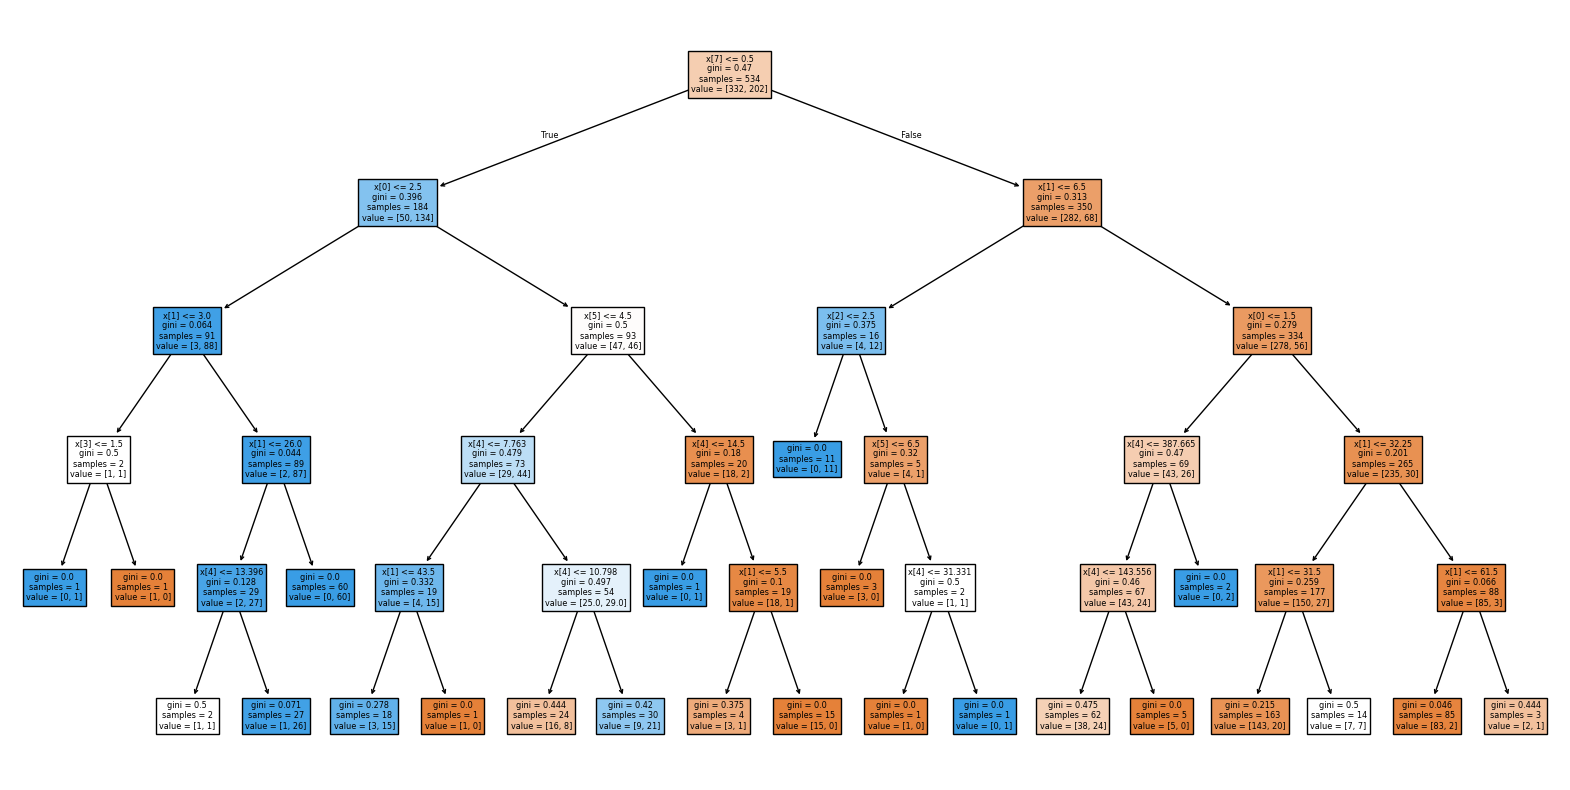

In [208]:
plt.figure(figsize=(20,10))
plot_tree(model,filled=True)
plt.show()

In [209]:
y_pred = model.predict(X_test)

In [210]:
print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))
print("Accuracy Score: ",accuracy_score(y_test,y_pred))

Confusion Matrix:  [[93 12]
 [29 45]]
Classification Report:                precision    recall  f1-score   support

           0       0.76      0.89      0.82       105
           1       0.79      0.61      0.69        74

    accuracy                           0.77       179
   macro avg       0.78      0.75      0.75       179
weighted avg       0.77      0.77      0.76       179

Accuracy Score:  0.770949720670391


## LAB 6

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [215]:
news = fetch_20newsgroups()

In [216]:
train = fetch_20newsgroups(subset="train")
test = fetch_20newsgroups(subset="test")

In [218]:
print(train.target_names)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [5]:
categories = ['alt.atheism', 'comp.graphics', 'sci.space']

In [6]:
train = fetch_20newsgroups(subset="train",categories=categories)
test = fetch_20newsgroups(subset="test",categories=categories)

In [221]:
print(train.target_names)

['alt.atheism', 'comp.graphics', 'sci.space']


In [222]:
print(train.data[5])

From: dietz@cs.rochester.edu (Paul Dietz)
Subject: Commercial mining activities on the moon
Organization: University of Rochester
Lines: 38

In article <1993Apr20.152819.28186@ke4zv.uucp> gary@ke4zv.UUCP (Gary Coffman) writes:

 > be the site of major commercial activity. As far as we know it has no
 > materials we can't get cheaper right here on Earth or from asteroids
 > and comets, aside from the semi-mythic He3 that *might* be useful in low
 > grade fusion reactors.

I don't know what a "low grade" fusion reactor is, but the major
problem with 3He (aside from the difficulty in making any fusion
reactor work) is that its concentration in lunar regolith is just so
small -- on the order of 5 ppb or so, on average (more in some
fractions, but still very small).  Massive amounts of regolith would
have to be processed.

This thread reminds me of Wingo's claims some time ago about the moon
as a source of titanium for use on earth.  As I recall, Wingo wasn't
content with being assured that

In [227]:
print("Data size: ",len(train.data))
print("Target size: ",train.target.shape)

Data size:  1657
Target size:  (1657,)


In [228]:
print(train.filenames)

['/home/badam/scikit_learn_data/20news_home/20news-bydate-train/sci.space/60869'
 '/home/badam/scikit_learn_data/20news_home/20news-bydate-train/comp.graphics/38633'
 '/home/badam/scikit_learn_data/20news_home/20news-bydate-train/alt.atheism/53534'
 ...
 '/home/badam/scikit_learn_data/20news_home/20news-bydate-train/sci.space/60915'
 '/home/badam/scikit_learn_data/20news_home/20news-bydate-train/sci.space/60176'
 '/home/badam/scikit_learn_data/20news_home/20news-bydate-train/sci.space/60929']


In [7]:
cv = CountVectorizer(min_df=5)
X_train = cv.fit_transform(train.data)
X_test = cv.transform(test.data)

In [232]:
bnb = BernoulliNB()
bnb.fit(X_train,train.target)

BernoulliNB()

In [233]:
y_pred = bnb.predict(X_test)

In [234]:
print("Confusion Matrix: ",confusion_matrix(test.target,y_pred))
print("Classification Report: ",classification_report(test.target,y_pred))
print("Accuracy Score: ",accuracy_score(test.target,y_pred))

Confusion Matrix:  [[270  47   2]
 [  5 373  11]
 [  7  90 297]]
Classification Report:                precision    recall  f1-score   support

           0       0.96      0.85      0.90       319
           1       0.73      0.96      0.83       389
           2       0.96      0.75      0.84       394

    accuracy                           0.85      1102
   macro avg       0.88      0.85      0.86      1102
weighted avg       0.88      0.85      0.85      1102

Accuracy Score:  0.852994555353902


In [235]:
print(y_pred)

[2 1 1 ... 0 1 2]


In [236]:
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(train.data)
X_test = tfidf.transform(test.data)

In [238]:
mnb = MultinomialNB()
mnb.fit(X_train,train.target)

MultinomialNB()

In [239]:
y_pred = mnb.predict(X_test)

In [240]:
print("Confusion Matrix: ",confusion_matrix(test.target,y_pred))
print("Classification Report: ",classification_report(test.target,y_pred))
print("Accuracy Score: ",accuracy_score(test.target,y_pred))

Confusion Matrix:  [[303   2  14]
 [  6 357  26]
 [  2   8 384]]
Classification Report:                precision    recall  f1-score   support

           0       0.97      0.95      0.96       319
           1       0.97      0.92      0.94       389
           2       0.91      0.97      0.94       394

    accuracy                           0.95      1102
   macro avg       0.95      0.95      0.95      1102
weighted avg       0.95      0.95      0.95      1102

Accuracy Score:  0.9473684210526315


In [241]:
tfidf = TfidfVectorizer(stop_words="english")
X_train = tfidf.fit_transform(train.data)
X_test = tfidf.transform(test.data)

In [242]:
mnb = MultinomialNB()
mnb.fit(X_train,train.target)
y_pred = mnb.predict(X_test)

In [243]:
print("Confusion Matrix: ",confusion_matrix(test.target,y_pred))
print("Classification Report: ",classification_report(test.target,y_pred))
print("Accuracy Score: ",accuracy_score(test.target,y_pred))

Confusion Matrix:  [[301   3  15]
 [  4 370  15]
 [  1  11 382]]
Classification Report:                precision    recall  f1-score   support

           0       0.98      0.94      0.96       319
           1       0.96      0.95      0.96       389
           2       0.93      0.97      0.95       394

    accuracy                           0.96      1102
   macro avg       0.96      0.95      0.96      1102
weighted avg       0.96      0.96      0.96      1102

Accuracy Score:  0.9555353901996371


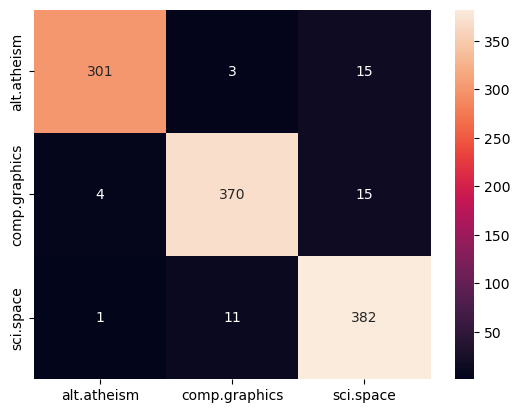

In [250]:
sns.heatmap(
    confusion_matrix(test.target,y_pred),
    annot=True, fmt="d",
    xticklabels=categories,
    yticklabels=categories
)
plt.show()

## LAB 7

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
data_test = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB7/Week7_test.csv")
data_train = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB7/Week7_train.csv")

In [4]:
print("Train shape: ",data_train.shape)
print("Test shape: ",data_test.shape)

Train shape:  (42000, 785)
Test shape:  (28000, 784)


In [5]:
data = pd.concat([data_test,data_train])
data = data.dropna()
data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.0


In [6]:
X_full = data.drop("label",axis=1)
y_full = data["label"]

In [7]:
y_full.isnull().sum()

np.int64(0)

In [8]:
print("X shape: ",X_full.shape)
print("y shape: ",y_full.shape)

X shape:  (42000, 784)
y shape:  (42000,)


In [9]:
sample_size = int(0.1*len(data))
X_train = X_full[:sample_size]
y_train = y_full[:sample_size]

In [10]:
print("X shape: ",X_train.shape)
print("y shape: ",y_train.shape)

X shape:  (4200, 784)
y shape:  (4200,)


In [11]:
X_train.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
y_train.nunique()

10

In [13]:
y_train.value_counts()

label
1.0    460
2.0    454
6.0    436
7.0    427
0.0    425
4.0    409
8.0    404
9.0    401
5.0    398
3.0    386
Name: count, dtype: int64

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_full,y_full,test_size=0.25,random_state=42)

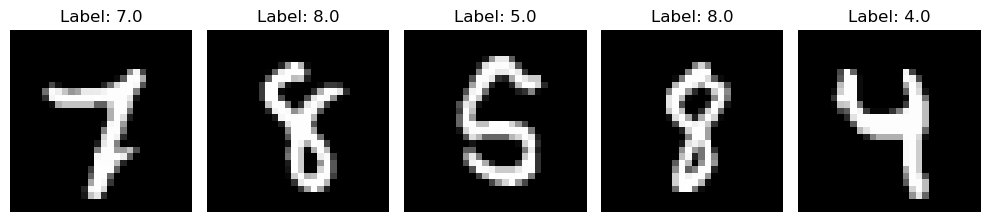

In [15]:
plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train.iloc[i].values.reshape(28,28),cmap="grey")
    plt.title(f"Label: {y_train.iloc[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
knn = KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [17]:
y_pred = knn.predict(X_test)

In [18]:
# ---------------------------------------------------
# 15. Print confusion matrix
# ---------------------------------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ---------------------------------------------------
# 16. Print classification report and accuracy
# ---------------------------------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Confusion Matrix:
[[1022    0    0    0    0    0    3    0    0    0]
 [   0 1143    0    0    0    0    3    0    0    0]
 [   9   17 1014    3    2    2    2   22    1    0]
 [   2    5    4 1110    0   10    2    6    5    7]
 [   2    7    0    0  993    0    3    1    0   18]
 [   2    2    0   19    1  861    9    0    1    3]
 [   8    2    0    0    0    2  997    0    1    0]
 [   0   26    2    0    2    0    0 1088    0   17]
 [   1   14    2   18    3   18    4    1  936    8]
 [   6    3    1   12   10    0    0   14    2  986]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      1025
         1.0       0.94      1.00      0.97      1146
         2.0       0.99      0.95      0.97      1072
         3.0       0.96      0.96      0.96      1151
         4.0       0.98      0.97      0.98      1024
         5.0       0.96      0.96      0.96       898
         6.0       0.97      0.99      0.98    

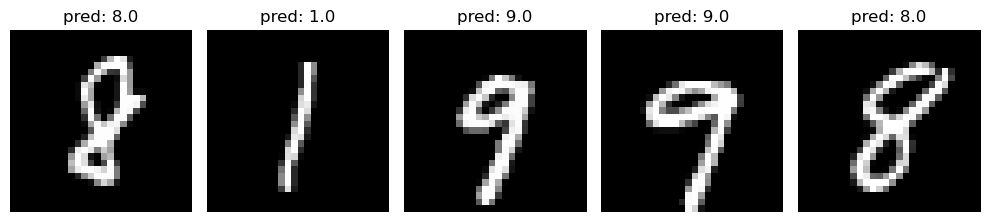

In [24]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28),cmap="grey")
    plt.title(f"pred: {y_pred[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## LAB 8

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

In [2]:
data = load_iris()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df["target"].unique()

array([0, 1, 2])

In [6]:
print(df["target"].value_counts())
print(df.isnull().sum())

target
0    50
1    50
2    50
Name: count, dtype: int64
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


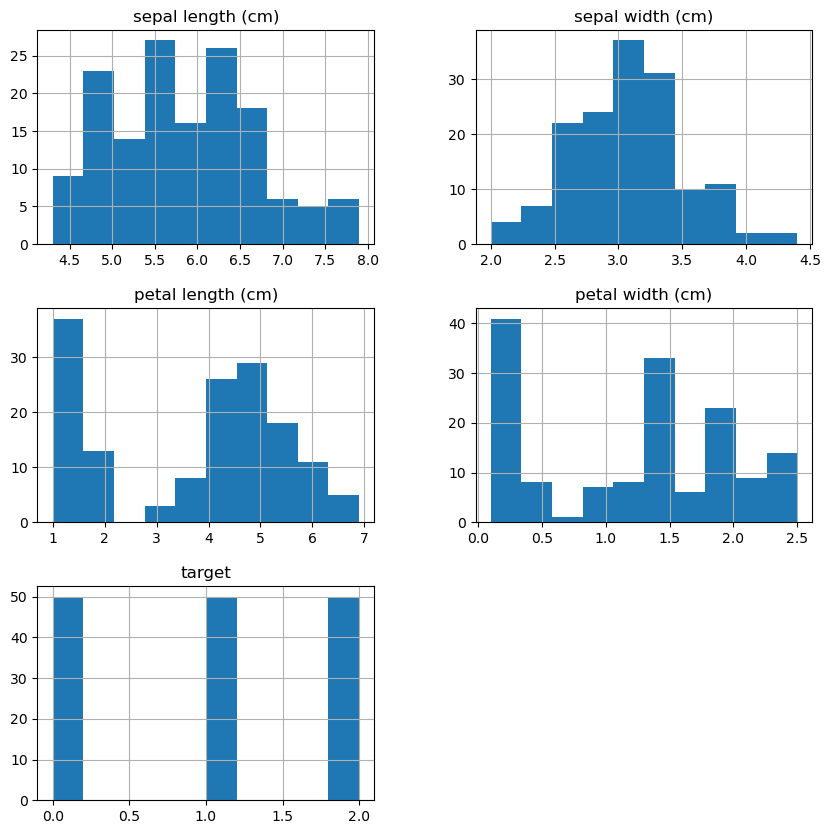

In [7]:
df.hist(figsize=(10,10))
plt.show()

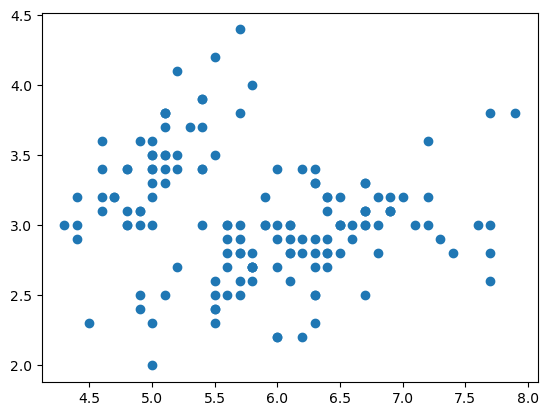

In [8]:
plt.scatter(df["sepal length (cm)"],df["sepal width (cm)"])
plt.show()

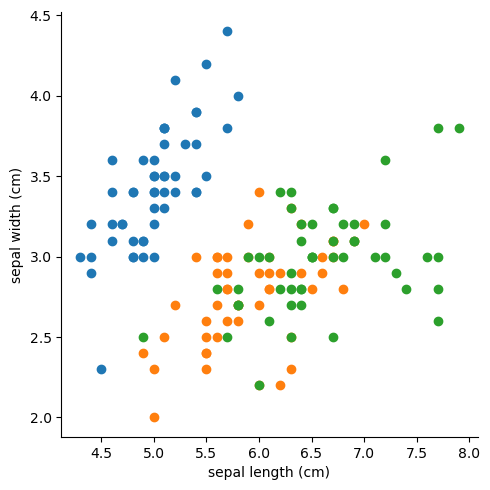

In [9]:
sns.FacetGrid(df,hue="target",height=5).map(plt.scatter,'sepal length (cm)','sepal width (cm)')
plt.show()

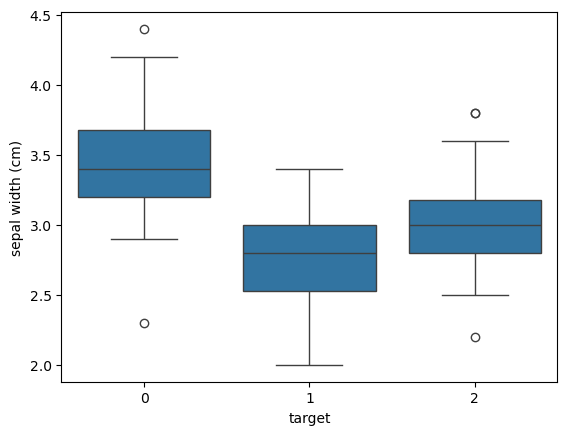

In [10]:
sns.boxplot(x="target",y="sepal width (cm)",data=df)
plt.show()

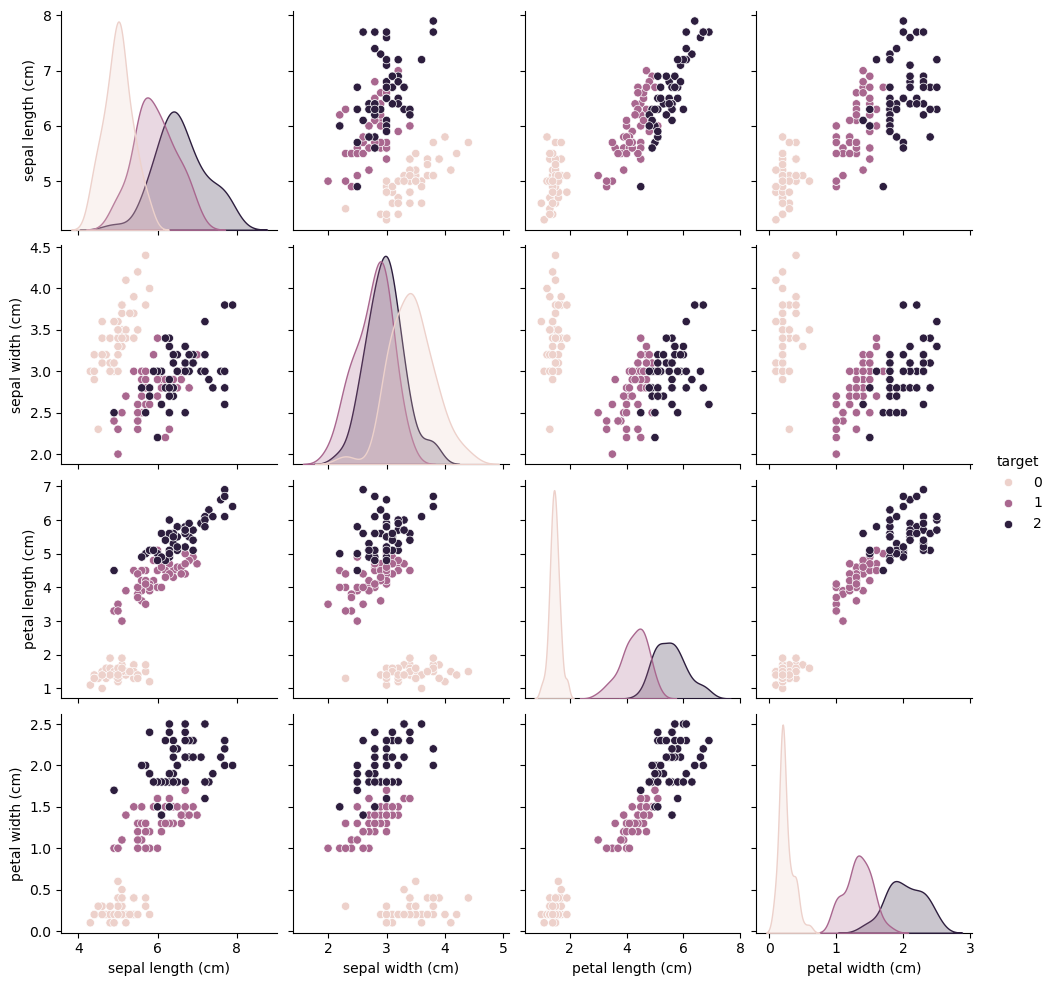

In [11]:
sns.pairplot(data=df,hue="target")
plt.show()

In [12]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


In [13]:
X = df.drop("target",axis=1)
y = df["target"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [17]:
svc = SVC(C=1)

In [18]:
svc.fit(X_train,y_train)

SVC(C=1)

In [19]:
y_pred = svc.predict(X_test)

[[14  0  0]
 [ 0 17  1]
 [ 0  0 13]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        18
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



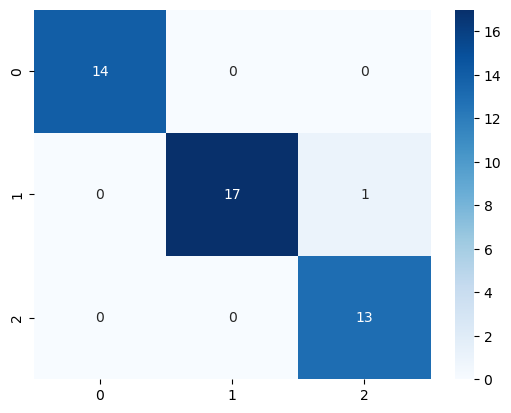

In [22]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test,y_pred))
# plot the confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues',fmt='g')
plt.show()

In [23]:
scores = cross_val_score(svc,X,y,cv=5)
print(scores)

[0.96666667 0.96666667 0.96666667 0.93333333 1.        ]


In [24]:
param_grid = {
    "C":[0.1,1,10,100,1000]
}
grid = GridSearchCV(SVC(),param_grid,cv=5)

In [25]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(), param_grid={'C': [0.1, 1, 10, 100, 1000]})

In [26]:
grid.best_params_

{'C': 10}

In [28]:
grid.cv_results_

{'mean_fit_time': array([0.00597353, 0.00397234, 0.00504141, 0.00441523, 0.00326314]),
 'std_fit_time': array([0.00038286, 0.00083775, 0.00076512, 0.00074425, 0.00016184]),
 'mean_score_time': array([0.00389738, 0.00290437, 0.00347276, 0.00297246, 0.00221953]),
 'std_score_time': array([3.81374389e-04, 7.42774545e-04, 4.88588173e-04, 6.44195152e-04,
        8.79286427e-05]),
 'param_C': masked_array(data=[0.1, 1.0, 10.0, 100.0, 1000.0],
              mask=[False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'C': 0.1}, {'C': 1}, {'C': 10}, {'C': 100}, {'C': 1000}],
 'split0_test_score': array([0.71428571, 1.        , 1.        , 1.        , 1.        ]),
 'split1_test_score': array([0.85714286, 0.95238095, 0.95238095, 0.9047619 , 0.95238095]),
 'split2_test_score': array([0.85714286, 1.        , 1.        , 1.        , 0.95238095]),
 'split3_test_score': array([0.80952381, 0.9047619 , 0.95238095, 0.9047619 , 0.9047619 ]),
 'split4_test_score': array([0.71428571, 

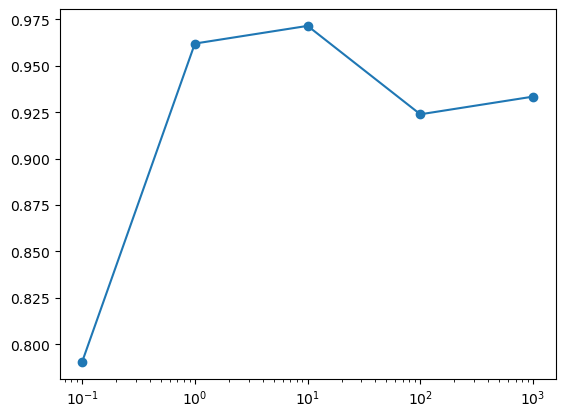

In [30]:
plt.plot(param_grid["C"],grid.cv_results_["mean_test_score"],marker="o")
plt.xscale('log')
plt.show()

In [31]:
print(grid.best_score_)
print(grid.best_params_)

0.9714285714285715
{'C': 10}


### LAB 10

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

In [33]:
df = pd.read_csv("/home/badam/Documents/ML/ML_LAB/Mall_Customers.csv")

In [34]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
df.shape

(200, 5)

In [37]:
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [38]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [39]:
wcss = []

In [40]:
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

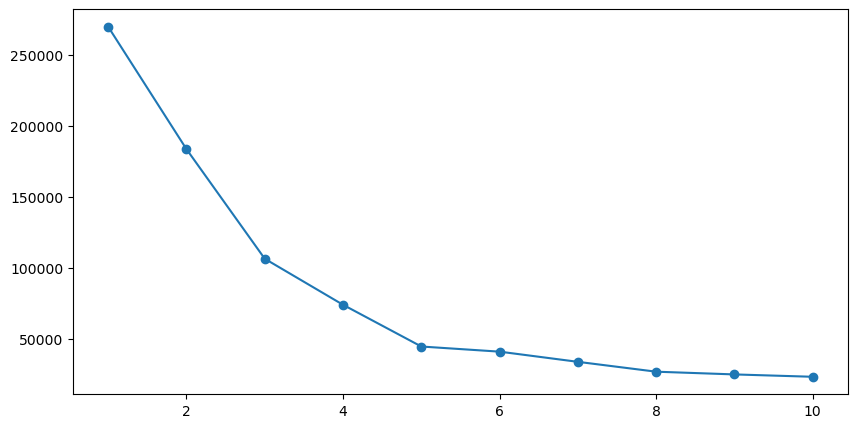

In [41]:
plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o')
plt.show()

In [42]:
kmeans = KMeans(n_clusters=5,random_state=42)

In [43]:
y_pred = kmeans.fit_predict(X)
print("Cluster Labels: ", y_pred)

Cluster Labels:  [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## OLS

In [44]:
import statsmodels.api as sm

In [45]:
df = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB4/Housing.csv")

In [46]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [47]:
df = pd.get_dummies(df,drop_first=True)

In [48]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [49]:
X = df.drop("price",axis=1)
y = df["price"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
X_ols = X
X_ols = sm.add_constant(X_ols)
X_ols = X_ols.astype(float)
y_ols = y

In [55]:
X_ols.dtypes

const                              float64
area                               float64
bedrooms                           float64
bathrooms                          float64
stories                            float64
parking                            float64
mainroad_yes                       float64
guestroom_yes                      float64
basement_yes                       float64
hotwaterheating_yes                float64
airconditioning_yes                float64
prefarea_yes                       float64
furnishingstatus_semi-furnished    float64
furnishingstatus_unfurnished       float64
dtype: object

In [56]:
model = sm.OLS(y_ols,X_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          9.07e-123
Time:                        17:05:11   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [58]:
SL = 0.05 

while True:
    model = sm.OLS(y_ols,X_ols).fit()
    pvalues = model.pvalues

    max_p = pvalues.max()
    if max_p > SL:
        feature_to_remove = pvalues.idxmax()
        print(f"removing: {feature_to_remove}, p-val: {max_p:.4f}")
        X_ols = X_ols.drop(columns=[feature_to_remove],axis=1)
    else:
        break

removing: const, p-val: 0.8715
removing: furnishingstatus_semi-furnished, p-val: 0.7156
removing: bedrooms, p-val: 0.0509


In [59]:
model = sm.OLS(y_ols,X_ols).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):                        0.00
Time:                        17:08:51   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

## LAB 7

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
train = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB7/Week7_train.csv")
test = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB7/Week7_test.csv")

In [4]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = pd.concat([train,test])
data.dropna(inplace=True)
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data.shape

(42000, 785)

In [7]:
X = data.drop("label",axis=1)
y = data["label"]

In [8]:
data["label"].nunique()

10

In [9]:
data["label"].value_counts()

label
1.0    4684
7.0    4401
3.0    4351
9.0    4188
2.0    4177
6.0    4137
0.0    4132
4.0    4072
8.0    4063
5.0    3795
Name: count, dtype: int64

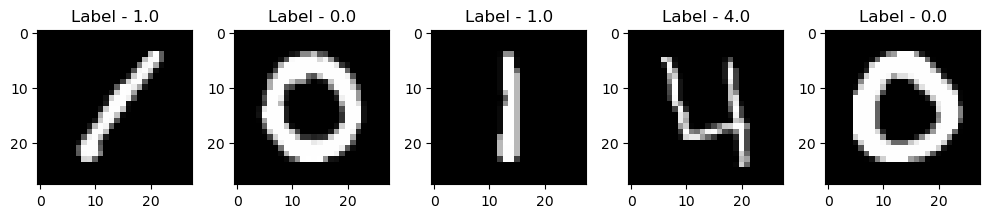

In [10]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28), cmap="grey")
    plt.title(f"Label - {y.iloc[i]}")
plt.tight_layout()
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [12]:
knn = KNeighborsClassifier(n_neighbors=5,metric="minkowski",p=2)

In [13]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [14]:
y_pred = knn.predict(X_test)

In [15]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[1022    0    0    0    0    0    3    0    0    0]
 [   0 1143    0    0    0    0    3    0    0    0]
 [   9   17 1014    3    2    2    2   22    1    0]
 [   2    5    4 1110    0   10    2    6    5    7]
 [   2    7    0    0  993    0    3    1    0   18]
 [   2    2    0   19    1  861    9    0    1    3]
 [   8    2    0    0    0    2  997    0    1    0]
 [   0   26    2    0    2    0    0 1088    0   17]
 [   1   14    2   18    3   18    4    1  936    8]
 [   6    3    1   12   10    0    0   14    2  986]]
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98      1025
         1.0       0.94      1.00      0.97      1146
         2.0       0.99      0.95      0.97      1072
         3.0       0.96      0.96      0.96      1151
         4.0       0.98      0.97      0.98      1024
         5.0       0.96      0.96      0.96       898
         6.0       0.97      0.99      0.98      1010
         7.0       0.96      0.96   

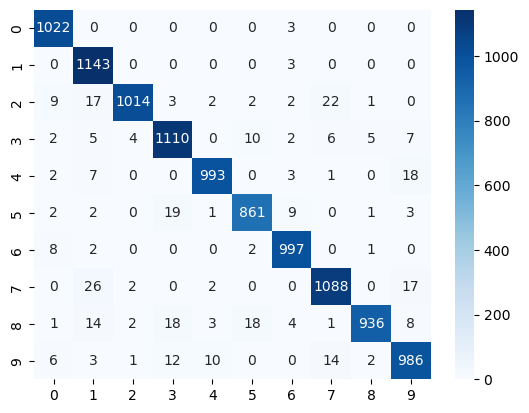

In [21]:
sns.heatmap(confusion_matrix(y_test,y_pred),cmap="Blues", annot=True, fmt='d')
plt.show()

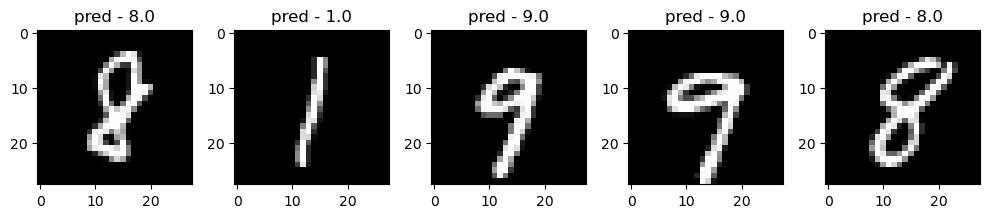

In [17]:
plt.figure(figsize=(10,5))    
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28),cmap="grey")
    plt.title(f"pred - {y_pred[i]}")
plt.tight_layout()
plt.show()

## LAB 8

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.svm import SVC

In [63]:
data = load_iris()

In [64]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"] = data.target

In [65]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [66]:
df["target"].unique()

array([0, 1, 2])

In [67]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [68]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [69]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


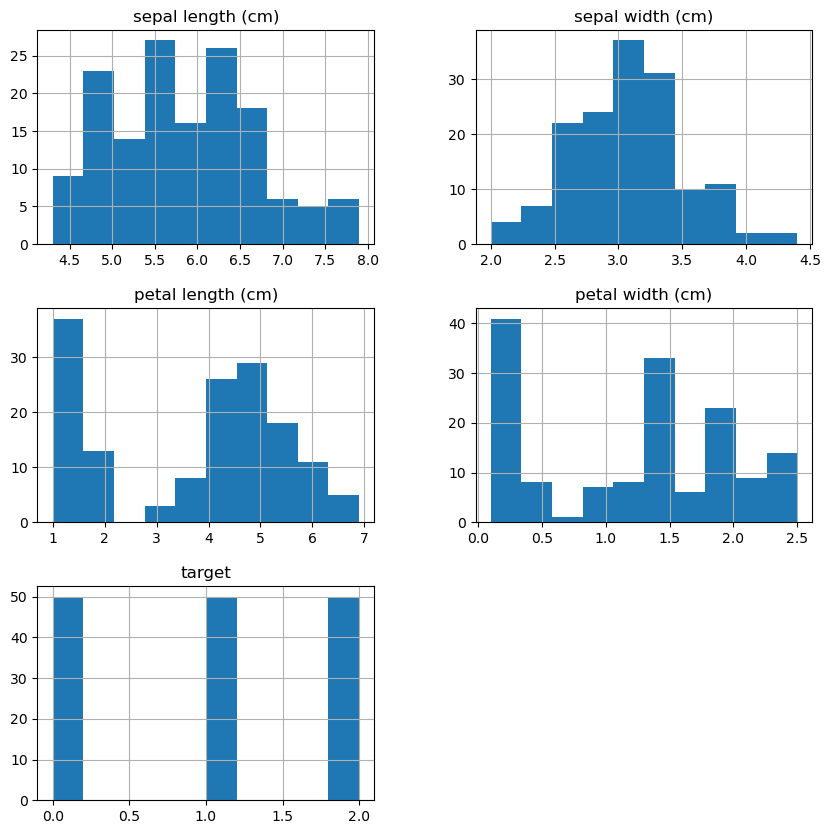

In [70]:
df.hist(figsize=(10,10))
plt.show()

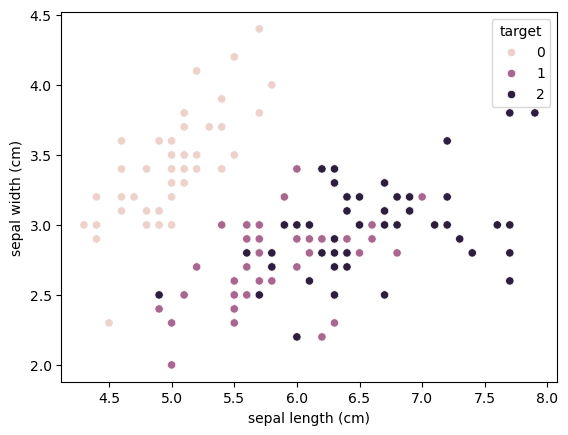

In [71]:
sns.scatterplot(x="sepal length (cm)",y="sepal width (cm)", hue="target",data=df)
plt.show()

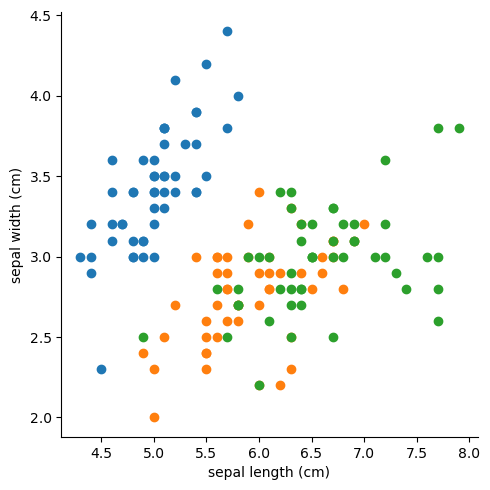

In [72]:
sns.FacetGrid(df,hue="target",height=5).map(plt.scatter,'sepal length (cm)','sepal width (cm)')
plt.show()

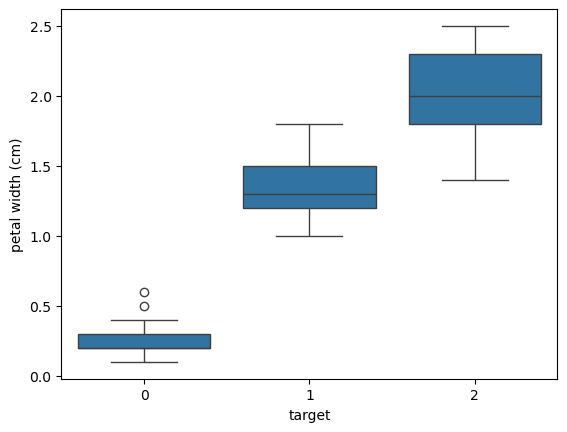

In [73]:
sns.boxplot(y="petal width (cm)", x="target" ,data=df)
plt.show()

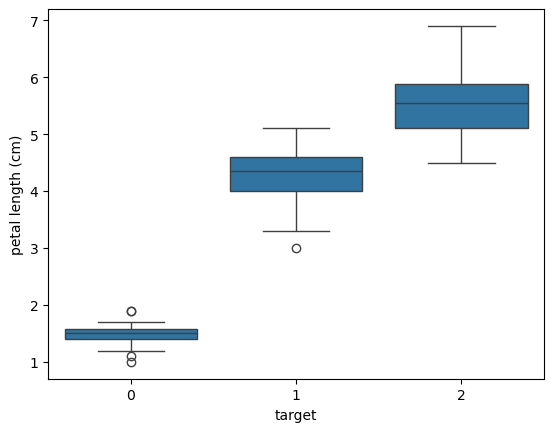

In [74]:
sns.boxplot(x="target",y="petal length (cm)",data=df)
plt.show()

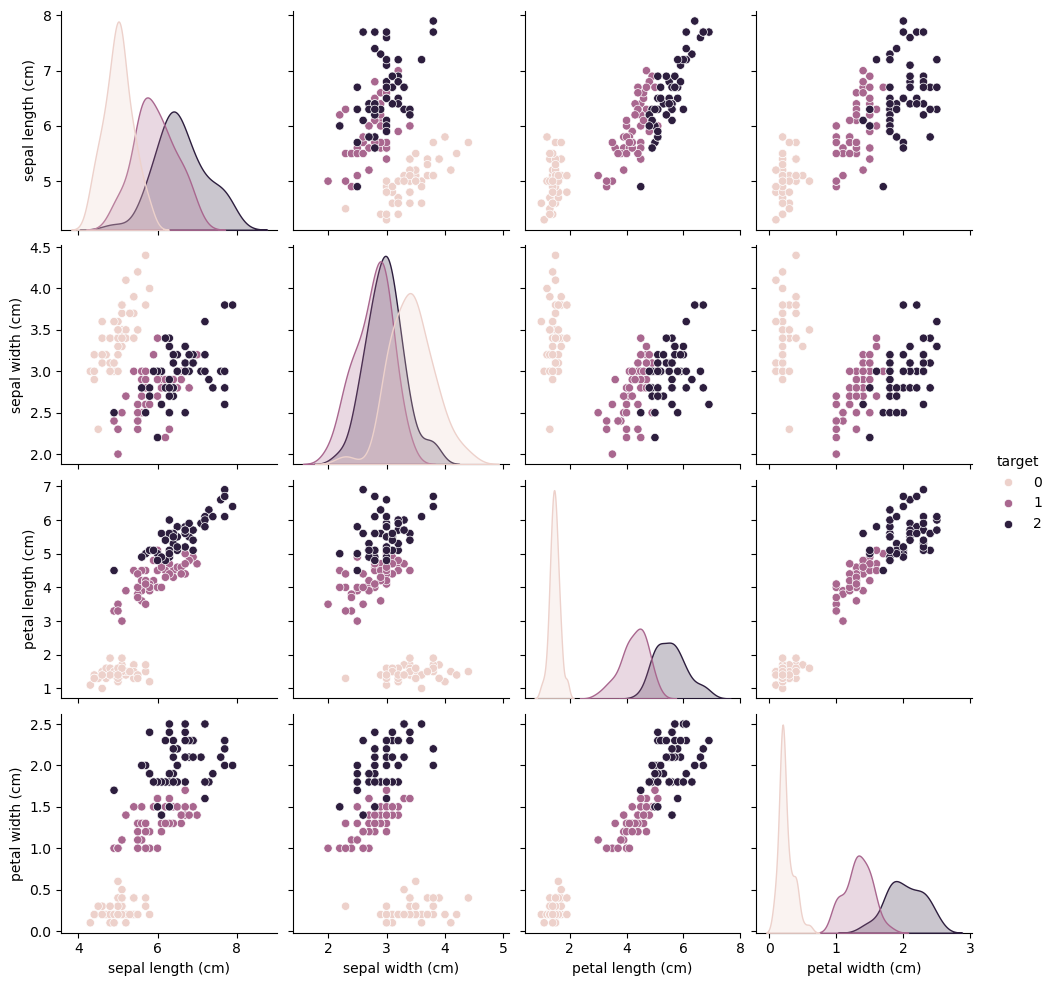

In [51]:
sns.pairplot(data=df,hue="target")
plt.show()

In [75]:
df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


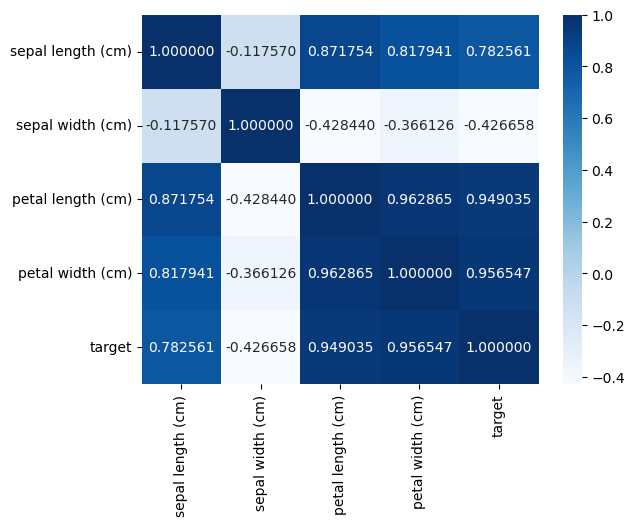

In [76]:
sns.heatmap(df.corr(),cmap="Blues",annot=True,fmt="f")
plt.show()

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [78]:
svm = SVC(C=1)
svm.fit(X_train,y_train)

SVC(C=1)

In [79]:
y_pred = svm.predict(X_test)

In [80]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[1237    0    0    0    1    3    4    1    1    0]
 [   0 1387    1    3    1    0    0    1    1    1]
 [   1    1 1228    2    5    1    3    6    8    2]
 [   1    1   12 1269    0   15    2    6    8    7]
 [   1    1    4    0 1208    1    2    4    0   11]
 [   4    2    1   14    1 1074    9    0    3    3]
 [   4    0    2    0    5    3 1243    0    1    0]
 [   0    3    7    0    5    1    0 1254    0   15]
 [   1    6    1    3    5   11    5    2 1210    5]
 [   6    1    2    4   14    2    1   14    2 1199]]
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1247
         1.0       0.99      0.99      0.99      1395
         2.0       0.98      0.98      0.98      1257
         3.0       0.98      0.96      0.97      1321
         4.0       0.97      0.98      0.98      1232
         5.0       0.97      0.97      0.97      1111
         6.0       0.98      0.99      0.98      1258
         7.0       0.97      0.98   

In [86]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [87]:
score = cross_val_score(SVC(),X_train,y_train,cv=5)
print(score)

[0.97414966 0.97006803 0.97057823 0.96751701 0.96904762]


In [88]:
param_grid = {
    "C":[0.1,1,10,100,1000]
}
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv = 5
)

In [89]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(), param_grid={'C': [0.1, 1, 10, 100, 1000]})

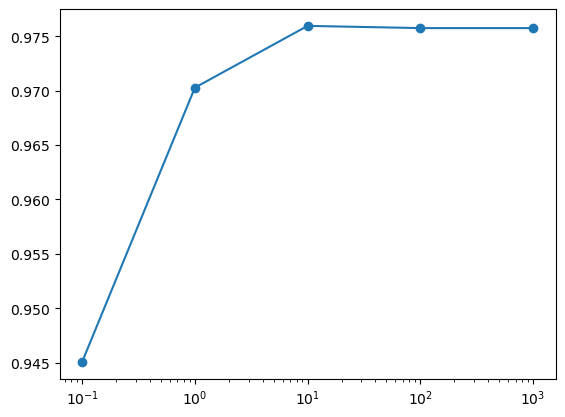

In [90]:
plt.plot(param_grid["C"],grid.cv_results_["mean_test_score"],marker="o")
plt.xscale('log')
plt.show()

In [92]:
print(grid.best_score_)
print(grid.best_params_)

0.9759523809523809
{'C': 10}


## LAB 7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
train = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB7/Week7_train.csv")
test = pd.read_csv("/home/badam/Documents/ML/ML_LAB/LAB7/Week7_test.csv")

In [3]:
df = pd.concat([train,test])
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(70000, 785)

In [5]:
size = int(0.1*len(df))
df1 = df[:size]

In [6]:
df1.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df1.shape

(7000, 785)

In [8]:
df.dropna(inplace=True)

In [9]:
df["label"].nunique()

10

In [10]:
df["label"].value_counts()

label
1.0    4684
7.0    4401
3.0    4351
9.0    4188
2.0    4177
6.0    4137
0.0    4132
4.0    4072
8.0    4063
5.0    3795
Name: count, dtype: int64

In [11]:
X = df.drop("label",axis=1)
y = df["label"]

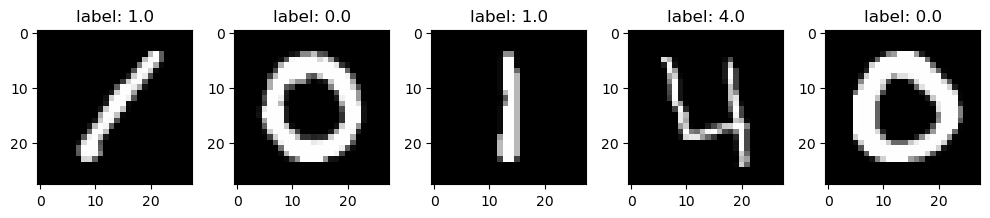

In [12]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28),cmap="gray")
    plt.title(f"label: {y.iloc[i]}")
plt.tight_layout()
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)

In [ ]:
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)

In [ ]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

In [ ]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test.iloc[i].values.reshape(28,28),cmap="gray")
    plt.title(f"pred: {y_pred.iloc[i]}")
plt.tight_layout()
plt.show()